<style>
body {
    max-width: 1200px;
    margin: auto;
    padding: 40px;
}
.jp-Notebook {
    max-width: 1200px;
    margin: auto;
}
.jp-CodeCell .jp-InputArea {
    display: none !important;
}
</style>

# Spotify Music Recommendation System

## Goal
- Analyze Spotify track/audio features
- Explore music patterns
- Build a similarity-based recommender system

## Dataset Overview

### Main Data Included
- Track metadata
  - song names
  - artists
  - playlists
  - popularity

- Audio features
  - danceability
  - energy
  - loudness
  - tempo
  - valence

- Additional information
  - lyrics
  - playlist context
  - duration
  - speechiness

### Dataset Size
- ~102,000 tracks
- 200+ extracted audio features

In [2]:
from pathlib import Path
import sys
import warnings

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config.paths import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH)

tracks = con.execute("""
    SELECT *
    FROM tracks
""").df()

print("Data loaded successfully.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data loaded successfully.


In [3]:
dataset_overview = pd.DataFrame({
    "Metric": [
        "Tracks",
        "Playlists",
        "Unique Artist IDs",
        "Unique Albums",
        "Tracks With Lyrics",
        "Tracks Without Lyrics"
    ],
    "Value": [
        len(tracks),
        tracks["playlist"].nunique(),
        tracks["artists_id"].nunique(),
        tracks["album_id"].nunique(),
        (tracks["lyrics"].astype(str).str.strip() != "").sum(),
        (tracks["lyrics"].astype(str).str.strip() == "").sum()
    ]
})

dataset_overview

,Metric,Value
0,Tracks,101939
1,Playlists,3800
2,Unique Artist IDs,54673
3,Unique Albums,75503
4,Tracks With Lyrics,101140
5,Tracks Without Lyrics,799


## Basic Data Understanding

### Goals of This Analysis
- Understand the general structure of the dataset
- Identify common track characteristics
- Detect potential data quality issues
- Explore feature variability before modeling

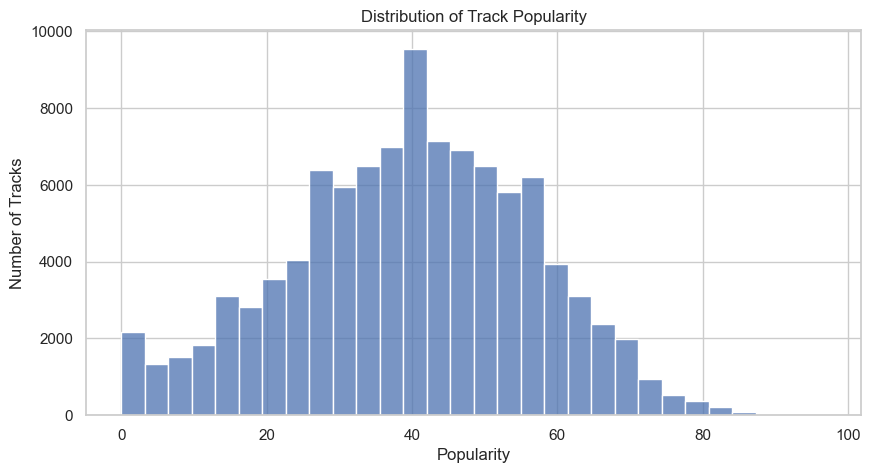

In [4]:
plt.figure(figsize=(10, 5))

sns.histplot(
    tracks["popularity"],
    bins=30
)

plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")

plt.show()

### Popularity Observations
- Most tracks fall into low-to-medium popularity ranges
- Only a smaller number of tracks are highly popular
- Dataset contains both mainstream and niche content

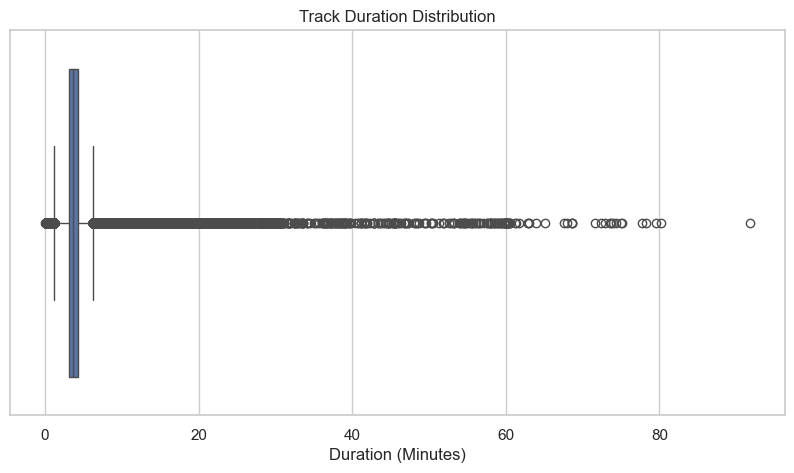

In [5]:
tracks["duration_min"] = tracks["duration_ms"] / 60000

plt.figure(figsize=(10, 5))

sns.boxplot(
    x=tracks["duration_min"]
)

plt.title("Track Duration Distribution")
plt.xlabel("Duration (Minutes)")

plt.show()

### Track Duration Distribution

- Most songs cluster in standard commercial lengths
- Long-duration tracks are relatively rare

## Audio Feature Exploration

### Main Features
- Danceability
- Energy
- Acousticness
- Loudness
- Speechiness
- Tempo
- Valence
- Instrumentalness

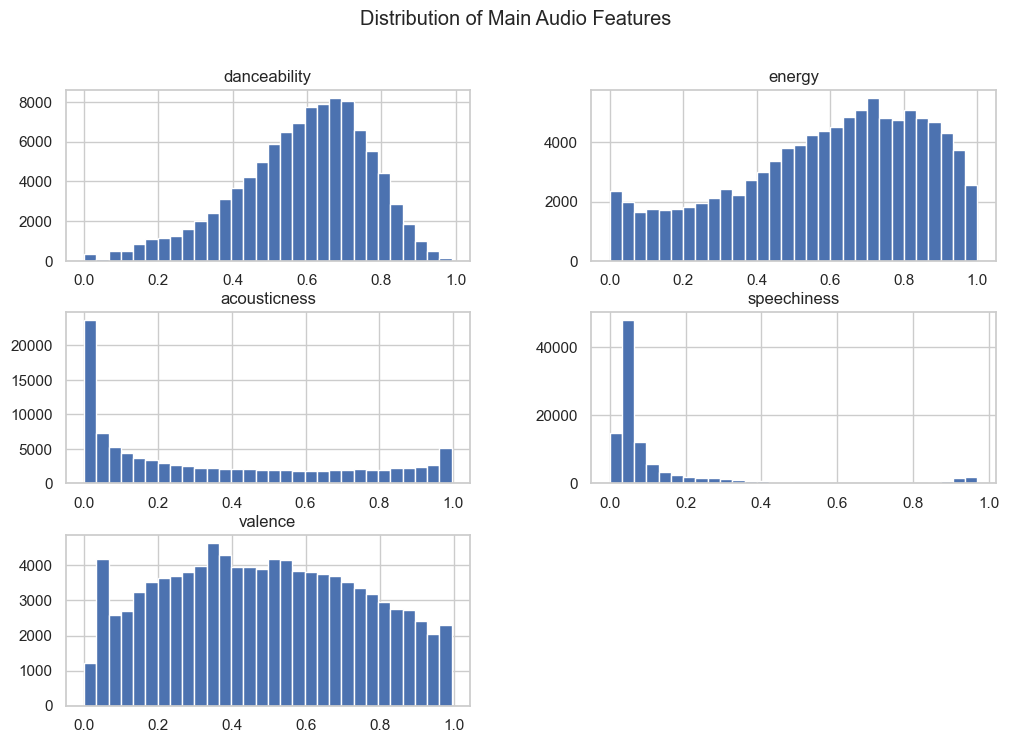

In [6]:
audio_cols = [
    "danceability",
    "energy",
    "acousticness",
    "speechiness",
    "valence"
]

tracks[audio_cols].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("Distribution of Main Audio Features")

plt.show()

### Distribution Observations
- Most features show broad variation across tracks
- Some features are concentrated around specific ranges
- Speechiness contains strong outliers due to spoken-word content
- Audio features provide useful diversity for recommendation models

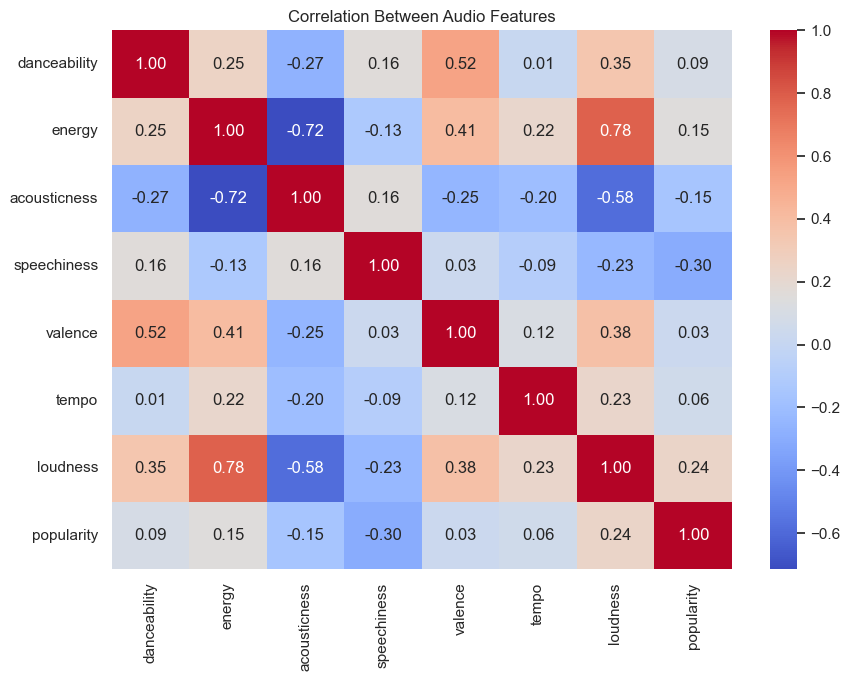

In [7]:
correlation_cols = [
    "danceability",
    "energy",
    "acousticness",
    "speechiness",
    "valence",
    "tempo",
    "loudness",
    "popularity"
]

correlation_matrix = tracks[
    correlation_cols
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Audio Features")

plt.show()

### Correlation Insights
- Energy and loudness are strongly connected
- Acoustic songs usually have lower energy
- Popularity is influenced by multiple features together

### Modeling Impact
- Features capture different song characteristics
- Supports similarity-based recommendations
- Motivates PCA and feature engineering

## Lyrics and Playlist Insights

### Additional Signals
- Lyrics information
- Playlist context
- Text diversity
- Listening environments

In [8]:
tracks["lyrics_word_count"] = (
    tracks["lyrics"]
    .astype(str)
    .str.replace(r"\r\n", " ", regex=True)
    .str.replace(r"\n", " ", regex=True)
    .str.strip()
    .apply(lambda x: len(x.split()))
)

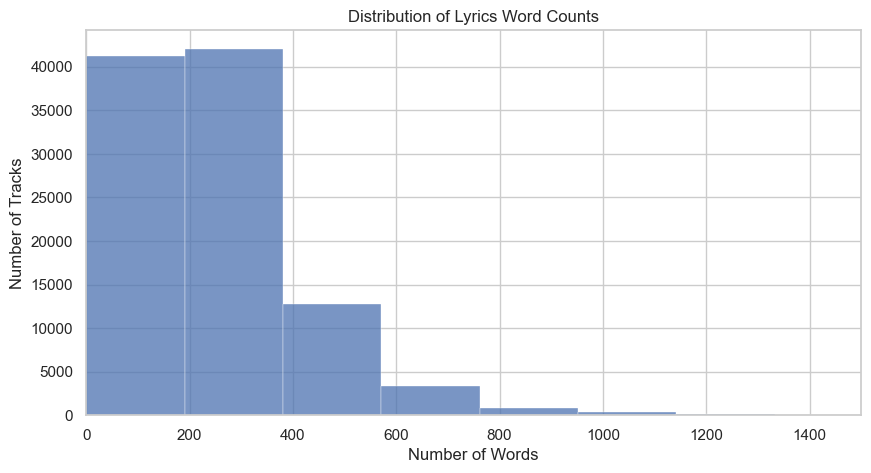

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(
    tracks["lyrics_word_count"],
    bins=200
)

plt.xlim(0, 1500)

plt.title("Distribution of Lyrics Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tracks")

plt.show()

### Lyrics Observations
- Most songs contain around 100–400 words
- Some tracks contain extremely large text bodies
- Lyrics distribution is highly skewed

### Likely Outliers
- Podcasts
- Audiobooks
- Spoken-word content

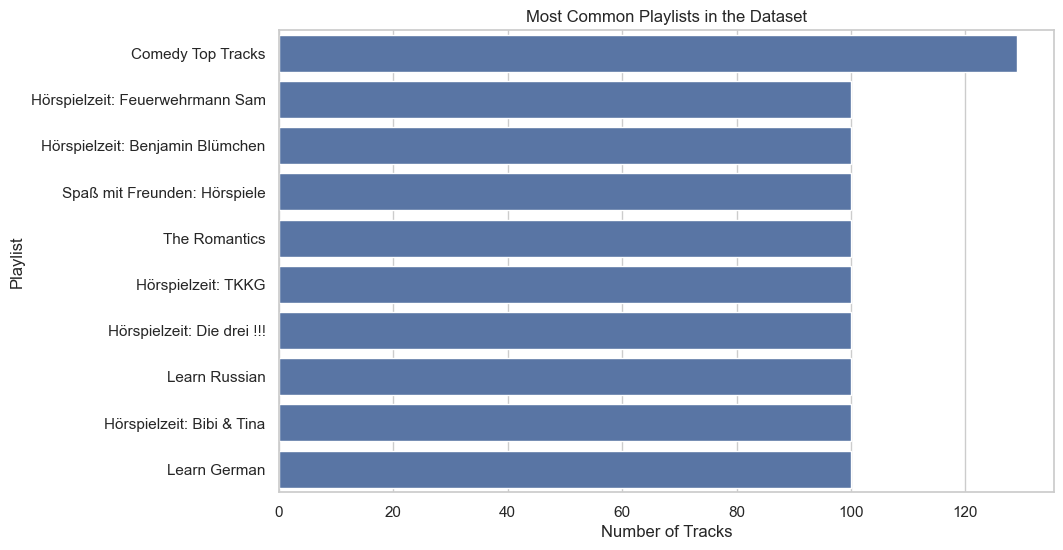

In [10]:
top_playlists = (
    tracks["playlist"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_playlists.values,
    y=top_playlists.index
)

plt.title("Most Common Playlists in the Dataset")
plt.xlabel("Number of Tracks")
plt.ylabel("Playlist")

plt.show()

### Main Observations
- The dataset contains many different playlist types
- Not all playlists represent traditional music
- Several playlists are focused on:
  - comedy
  - spoken-word content
  - audiobooks
  - language learning
- Playlist context could later improve recommendations

## Feature Scaling & Similarity

### What Was Done
- Numerical audio features were standardized
- Features originally had very different scales
- Standardization prevents one feature from dominating similarity calculations

### Main Features Used
- danceability
- energy
- acousticness
- loudness
- speechiness
- tempo
- valence
- popularity

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = [
    "danceability",
    "energy",
    "tempo",
    "loudness",
    "popularity"
]

scaled_audio_features = pd.DataFrame(
    scaler.fit_transform(
        tracks[scale_cols]
    ),
    columns=scale_cols
)

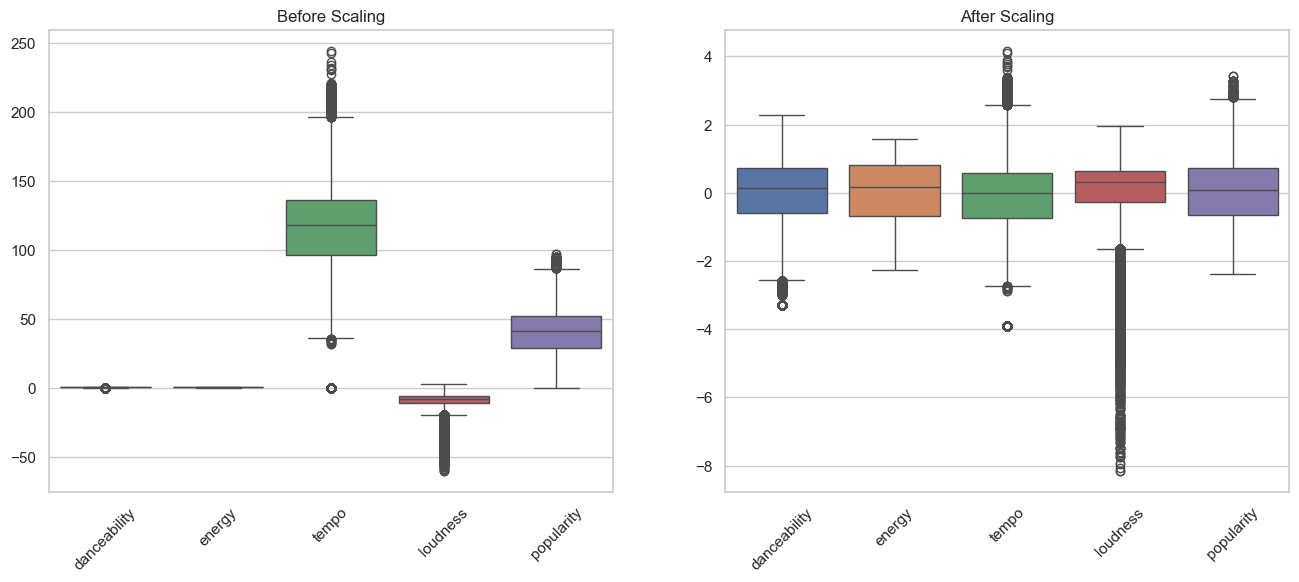

In [12]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

sns.boxplot(
    data=tracks[
        [
            "danceability",
            "energy",
            "tempo",
            "loudness",
            "popularity"
        ]
    ],
    ax=axes[0]
)

axes[0].set_title("Before Scaling")
axes[0].tick_params(axis="x", rotation=45)

scaled_subset = scaled_audio_features[
    [
        "danceability",
        "energy",
        "tempo",
        "loudness",
        "popularity"
    ]
]

sns.boxplot(
    data=scaled_subset,
    ax=axes[1]
)

axes[1].set_title("After Scaling")
axes[1].tick_params(axis="x", rotation=45)

plt.show()

### Main Observations
- Before scaling, features had very different ranges
- Tempo and popularity dominated the scale
- After scaling, all features are more balanced
- This helps similarity calculations work more fairly

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

similarity_input = scaled_audio_features[
    [
        "danceability",
        "energy",
        "tempo",
        "loudness",
        "popularity"
    ]
]

sample_similarity = cosine_similarity(
    similarity_input.sample(
        1000,
        random_state=42
    )
)

similarity_scores = sample_similarity.flatten()

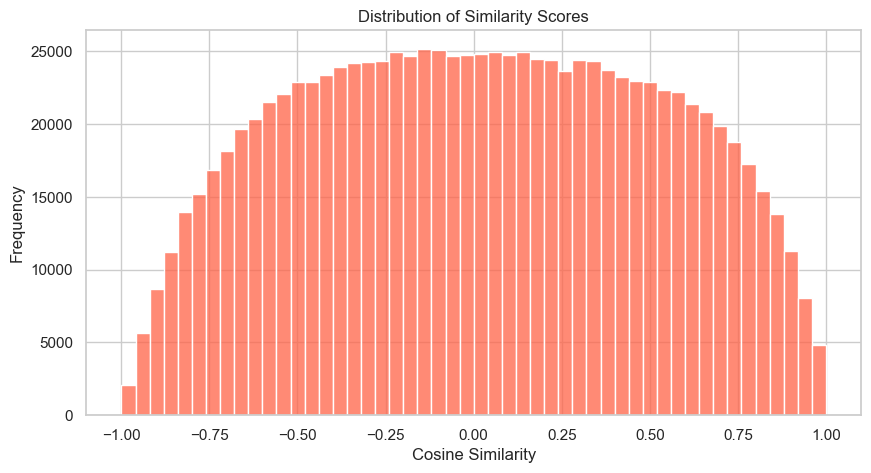

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    similarity_scores,
    bins=50,
    color="tomato"
)

plt.title("Distribution of Similarity Scores")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")

plt.show()

### Recommender Example

Instead of only looking at the full similarity distribution, we also tested the recommender on one selected song.

The goal here is simple:
- choose one song
- find the most similar tracks
- rank them by cosine similarity

In [31]:
# Create a small recommender sample

recommender_sample = tracks.sample(
    n=20000,
    random_state=42
).reset_index(drop=True)

recommender_features = [
    "danceability",
    "energy",
    "acousticness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
    "popularity"
]

scaler = StandardScaler()

recommender_scaled = scaler.fit_transform(
    recommender_sample[recommender_features]
)

recommender_similarity = cosine_similarity(
    recommender_scaled
)

In [32]:
def recommend_from_sample(track_name, n_recommendations=5):
    matches = recommender_sample[
        recommender_sample["name"]
        .str.lower()
        .str.contains(track_name.lower(), na=False)
    ]

    if matches.empty:
        return pd.DataFrame({
            "Message": [f"No track found for '{track_name}' in sample."]
        })

    selected_index = matches.index[0]
    selected_track = recommender_sample.loc[selected_index, "name"]

    scores = list(enumerate(recommender_similarity[selected_index]))

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    scores = scores[1:n_recommendations + 1]

    results = []

    for idx, score in scores:
        results.append({
            "Input Song": selected_track,
            "Recommended Song": recommender_sample.loc[idx, "name"],
            "Similarity Score": round(score, 3),
            "Popularity": recommender_sample.loc[idx, "popularity"]
        })

    return pd.DataFrame(results)

In [33]:
recommender_sample[
    ["name", "popularity"]
].sample(10, random_state=10)

,name,popularity
19778,Watan El Akk,28.0
4376,Irresponsables - En Vivo,52.0
10188,Werewere Lafinsere Wa Labule Oko Ogun Ajobo Un...,12.0
9887,Gunshot (feat. Benji Webbe),33.0
4441,Carajillo (feat. La Real),44.0
8455,Esto te pone la Cabeza Mala,34.0
6321,Worlds Apart,71.0
6328,Diya wo Ailan,20.0
4636,La valse des trottoirs,17.0
10347,The Times I'm Not There,54.0


In [34]:
recommendations = recommend_from_sample(
    "Billie Jean",
    n_recommendations=5
)

recommendations

,Input Song,Recommended Song,Similarity Score,Popularity
0,Billie Jean,The Nights,0.980,68.0
1,Billie Jean,Marry Me,0.977,73.0
2,Billie Jean,Self Control,0.969,74.0
3,Billie Jean,Youth,0.964,59.0
4,Billie Jean,Stand By Your Man,0.964,61.0


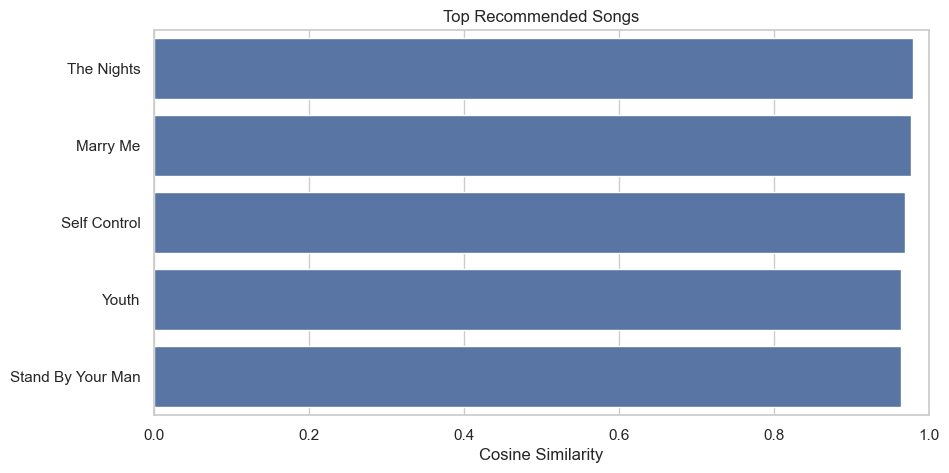

In [35]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=recommendations,
    x="Similarity Score",
    y="Recommended Song"
)

plt.title("Top Recommended Songs")
plt.xlabel("Cosine Similarity")
plt.ylabel("")

plt.xlim(0, 1)

plt.show()

### Main Observations
- The recommender successfully returns ranked song suggestions
- Recommended tracks receive high cosine similarity scores
- This shows that the feature-based similarity approach works technically
- Some recommendations are musically reasonable, while others are less intuitive
- This is expected because the current baseline only uses numerical audio features

### Current Limitation
- The recommender does not yet understand:
  - genre
  - artist relationships
  - lyrics meaning
  - listening behavior
- Because of this, some recommendations may sound mathematically similar but not contextually similar

## PCA Visualization

### Goal
- Reduce high-dimensional audio features into 2 dimensions
- Visualize how tracks are distributed
- Explore whether similar songs appear close together

### Why PCA?
- Audio features exist in many dimensions
- PCA compresses the information while preserving most variance
- Makes the dataset easier to visualize and interpret

In [26]:
from sklearn.decomposition import PCA

In [36]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(
    recommender_scaled
)

pca_df = pd.DataFrame({
    "PC1": pca_components[:, 0],
    "PC2": pca_components[:, 1],
    "track_name": recommender_sample["name"].values,
    "popularity": recommender_sample["popularity"].values
})

pca_df.head()

,PC1,PC2,track_name,popularity
0,-0.024896,-0.341436,Du tar hand om honom,28.0
1,-0.207599,0.450614,Não Vou Desistir,17.0
2,0.819896,0.038949,Pictures,50.0
3,-1.323219,4.196188,Maria Shriver - Women's History Month 2017,0.0
4,-1.808245,2.573496,"Games, Sports and Leisure Activities in Arabic",3.0


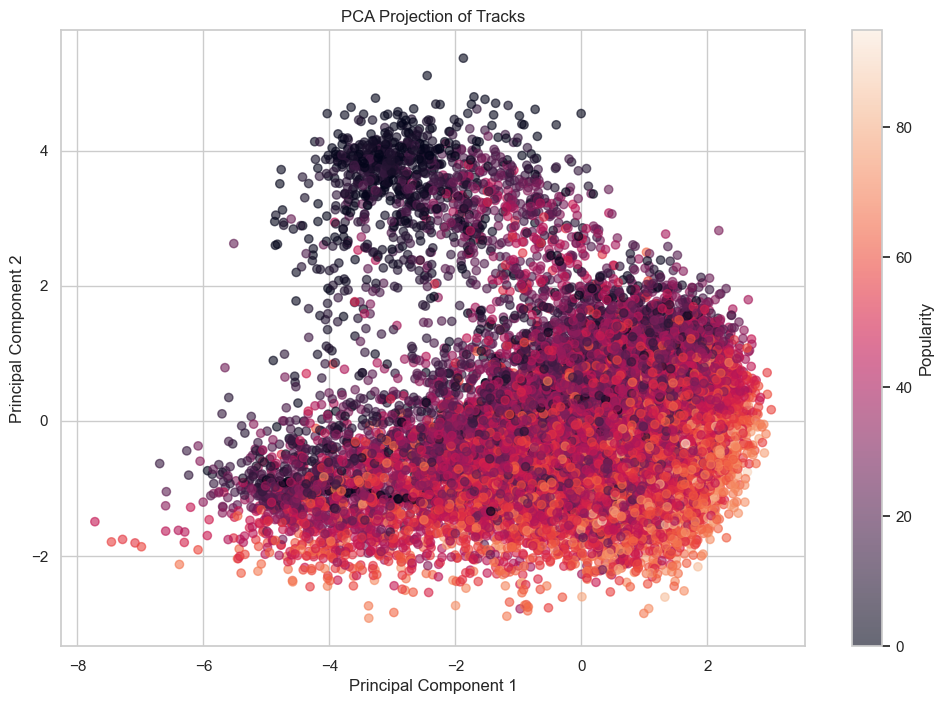

In [37]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["popularity"],
    alpha=0.6
)

plt.colorbar(scatter, label="Popularity")

plt.title("PCA Projection of Tracks")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [38]:
selected_song = "Billie Jean"

selected_row = pca_df[
    pca_df["track_name"]
    .str.lower()
    .str.contains(selected_song.lower(), na=False)
].head(1)

recommended_names = recommendations[
    "Recommended Song"
].tolist()

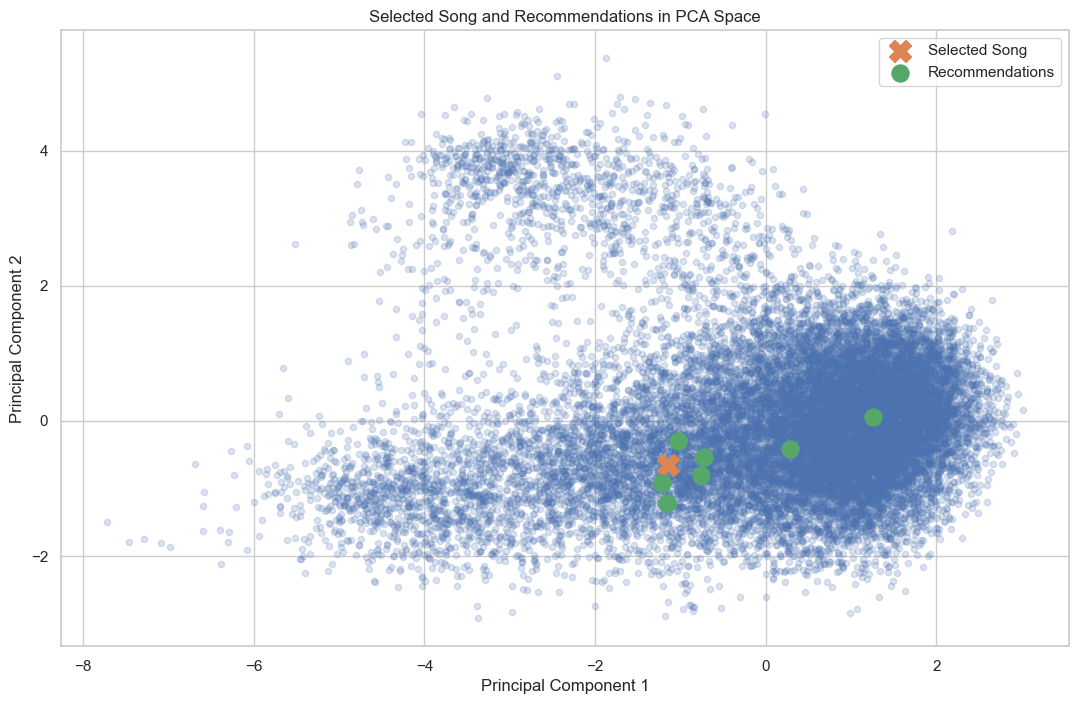

In [39]:
plt.figure(figsize=(13, 8))

# All songs
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.2,
    s=20
)

# Selected song
plt.scatter(
    selected_row["PC1"],
    selected_row["PC2"],
    s=250,
    marker="X",
    label="Selected Song"
)

# Recommended songs
recommended_points = pca_df[
    pca_df["track_name"].isin(recommended_names)
]

plt.scatter(
    recommended_points["PC1"],
    recommended_points["PC2"],
    s=150,
    label="Recommendations"
)

plt.title("Selected Song and Recommendations in PCA Space")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.show()

### Main Observations
- PCA reduces audio features into 2D space
- Similar songs appear closer together
- Recommendations cluster near the selected song

### Additional Notes
- Several song clusters become visible
- Some regions contain more niche content

### Limitation
- PCA simplifies the original feature space
- Some information is lost

## Models Considered

| Model | Purpose | Pros | Cons |
|---|---|---|---|
| Cosine Similarity | Measure similarity between feature vectors | Works well for numerical features | Ignores user behavior |
| Content-Based Filtering | Recommend songs using audio features | Simple and interpretable | Limited personalization |
| KNN Recommender | Find nearest songs in feature space | Intuitive and flexible | Sensitive to scaling |
| K-Means Clustering | Group similar songs together | Useful for discovery and exploration | Hard to tune properly |
| Lyrics-Based Similarity | Compare songs using lyrics/text | Adds semantic meaning | Heavy preprocessing needed |

### Why start with Cosine Similarity?
- Fast baseline implementation
- Easy to explain and visualize
- Works well with scaled audio features
- Good starting point before more advanced models

## Main Challenges

| Challenge | Explanation |
|---|---|
| Large dataset size | Similarity calculations become expensive |
| Mixed content | Dataset contains podcasts and non-music content |
| High dimensionality | Many audio features at once |
| Recommendation quality | Audio similarity does not always match human taste |

# Conclusion

### Completed
- Audio feature analysis
- Playlist analysis
- Lyrics analysis
- Feature scaling
- PCA visualization
- Baseline recommender

### Current Status
Baseline recommender successfully implemented and ready for further improvements.

## Planned Improvements

- Remove podcasts and spoken-word content
- Add lyrics-based features
- Implement KNN recommender
- Build interactive dashboard
- Improve recommendation quality